In [1]:
import pandas as pd

df = pd.read_csv("../../../Data/general_knowledge_qa.csv")
df.drop(columns=['question_type','image'],inplace=True)
df

,question,answer
0,How many days do we have in a week?,Seven
1,How many days are there in a normal year?,365 (not a leap year)
2,How many colors are there in a rainbow?,7
3,Which animal is known as the ‘Ship of the Dese...,Camel
4,How many letters are there in the English alph...,26
...,...,...
925,Where are the HeadQuarters of UNESCO?,"Paris, France"
926,Which are the colors of the rings of the Olymp...,"Black, Red, Blue, Green, and Yellow"
927,Who invented ‘Lift’?,Elisha Graves Otis
928,Which river crosses the equator twice?,Congo River


# 1. Tokenization

In [2]:
def tokenize(text):
    return (text.lower()
            .replace("?","")
            .replace("!","")
            .replace("'","")
            .replace(",","")
            .replace(".","")
            .replace(":","")
            .replace("(","")
            .replace(")","")
            .split())

In [3]:
tokenize("How many days do we have in a week?")

['how', 'many', 'days', 'do', 'we', 'have', 'in', 'a', 'week']

# 2. Build vocab

In [4]:
vocab = {
    "UNK":0
}

In [5]:
def build_vocab(row):
    question_tokens = tokenize(row['question'])
    answer_tokens = tokenize(row['answer'])
    
    merge_tokens = question_tokens + answer_tokens
    
    for token in merge_tokens:
        if token not in vocab:
            vocab[token] = len(vocab)

In [6]:
build_vocab(df.iloc[0,:])
vocab

{'UNK': 0,
 'how': 1,
 'many': 2,
 'days': 3,
 'do': 4,
 'we': 5,
 'have': 6,
 'in': 7,
 'a': 8,
 'week': 9,
 'seven': 10}

In [7]:
df.apply(build_vocab, axis=1)  # every row at a time
print(len(vocab))
vocab

2154


{'UNK': 0,
 'how': 1,
 'many': 2,
 'days': 3,
 'do': 4,
 'we': 5,
 'have': 6,
 'in': 7,
 'a': 8,
 'week': 9,
 'seven': 10,
 'are': 11,
 'there': 12,
 'normal': 13,
 'year': 14,
 '365': 15,
 'not': 16,
 'leap': 17,
 'colors': 18,
 'rainbow': 19,
 '7': 20,
 'which': 21,
 'animal': 22,
 'is': 23,
 'known': 24,
 'as': 25,
 'the': 26,
 '‘ship': 27,
 'of': 28,
 'desert’': 29,
 'camel': 30,
 'letters': 31,
 'english': 32,
 'alphabet': 33,
 '26': 34,
 'consonants': 35,
 '21': 36,
 'sides': 37,
 'triangle': 38,
 'three': 39,
 'month': 40,
 'has': 41,
 'least': 42,
 'number': 43,
 'february': 44,
 'vowels': 45,
 'series': 46,
 'e': 47,
 'i': 48,
 'o': 49,
 'u': 50,
 'called': 51,
 'king': 52,
 'jungle': 53,
 'lion': 54,
 'primary': 55,
 'red': 56,
 'yellow': 57,
 'blue': 58,
 '29': 59,
 'what': 60,
 'you': 61,
 'call': 62,
 'house': 63,
 'made': 64,
 'ice': 65,
 'igloo': 66,
 'largest': 67,
 'world': 68,
 'whale': 69,
 'tallest': 70,
 'on': 71,
 'earth': 72,
 'giraffe': 73,
 'festival': 74,
 'ho

# 3. Text to numeric representation

In [8]:
def text_to_numeric_rep(text, vocab):
    numerical_present = []
    for word in tokenize(text):
        if word in vocab:
            numerical_present.append(vocab[word])
        else:
            numerical_present.append(0)
    return numerical_present

In [9]:
text_to_numeric_rep("Which animal is known as the ‘Ship of the Desert?’",vocab)

[21, 22, 23, 24, 25, 26, 27, 28, 26, 29]

# 4. Dataloader

In [10]:
from torch.utils.data import Dataset, DataLoader
import torch

class CustomDataset(Dataset):
    def __init__(self, df, vocab):
        self.df = df
        self.vocab = vocab
    def __len__(self):
        return self.df.shape[0]
    
    def __getitem__(self, index):
        row = self.df.iloc[index]

        numerical_question = text_to_numeric_rep(row['question'], self.vocab)
        numerical_answer = text_to_numeric_rep(row['answer'], self.vocab)
        
        return torch.tensor(numerical_question), torch.tensor(numerical_answer)

In [11]:
dataset = CustomDataset(df,vocab)

dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

In [12]:
for ques, ans in dataloader:
    print(ques)
    print(ans)
    break

tensor([[  60,  739,   89,    8,  556, 1067]])
tensor([[1068]])


# 5. Model Build

In [13]:
import torch.nn as nn
class QuesAnsLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim = 50, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim=embedding_dim, padding_idx=0)
        self.embedding_dropout = nn.Dropout(dropout)
        
        self.lstm = nn.LSTM(
            input_size= embedding_dim,
            hidden_size= hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False,
            bias=True
        )
        
        # Regularization after LSTM
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, question):
        embedding_ques = self.embedding_dropout(self.embedding(question))
        
        # LSTM returns (output, (hidden_state, cell_states)) — unpack both hidden & 
        lstm_output , (hidden_state, cell_states) = self.lstm(embedding_ques)
        
        # Take last layer's hidden state
        last_hidden = hidden_state[-1]
        
        # LayerNorm + Dropout
        last_hidden = self.layer_norm(last_hidden)
        last_hidden = self.dropout(last_hidden)
        
        return self.fc(last_hidden)

# 6. Train Model

In [14]:
learning_rate = 0.001
epochs = 50

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [16]:
model = QuesAnsLSTM(len(vocab)).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [17]:
losses = []
for epoch in range(epochs):
    epochs_loss = 0
    for question, answer in dataloader:
        question, answer = question.to(device), answer.to(device)
        optimizer.zero_grad()
        
        y_pred = model(question)
        
        loss = criterion(y_pred, answer[:,0])
        
        loss.backward()
        
        optimizer.step()
        
        epochs_loss += loss.item()
        
    avg_epoch_loss = epochs_loss / len(dataloader)
    losses.append(avg_epoch_loss)
    print(f"Epoch {epoch+1}: Loss {avg_epoch_loss}")

Epoch 1: Loss 7.55085550219782
Epoch 2: Loss 6.199613936613964
Epoch 3: Loss 5.292447941449861
Epoch 4: Loss 4.3544081318122085
Epoch 5: Loss 3.6352048540708197
Epoch 6: Loss 2.896432360556097
Epoch 7: Loss 2.3536005370839628
Epoch 8: Loss 1.8524607770896007
Epoch 9: Loss 1.4808481950066252
Epoch 10: Loss 1.2702151724189783
Epoch 11: Loss 1.0685269774028516
Epoch 12: Loss 0.9305702272800713
Epoch 13: Loss 0.8429419310928713
Epoch 14: Loss 0.839040636327005
Epoch 15: Loss 0.6207107474175646
Epoch 16: Loss 0.6382134570520906
Epoch 17: Loss 0.5945803855833024
Epoch 18: Loss 0.6202868196959967
Epoch 19: Loss 0.5743948410592762
Epoch 20: Loss 0.5091127391247717
Epoch 21: Loss 0.5151697294185142
Epoch 22: Loss 0.5139970233236161
Epoch 23: Loss 0.43907428594635467
Epoch 24: Loss 0.3636753950690681
Epoch 25: Loss 0.3902036175027756
Epoch 26: Loss 0.40033389616298815
Epoch 27: Loss 0.38888341387428865
Epoch 28: Loss 0.4403601151955693
Epoch 29: Loss 0.4474883004236065
Epoch 30: Loss 0.336376081

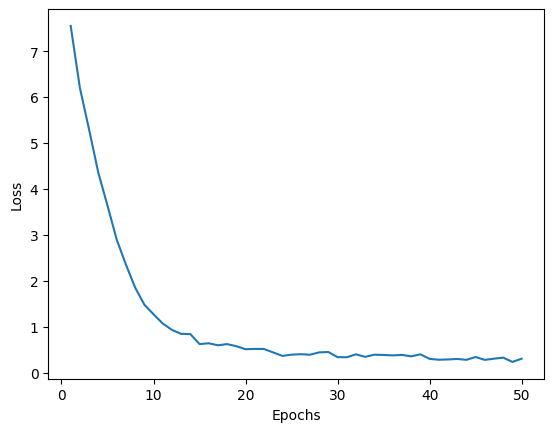

In [18]:
import matplotlib.pyplot as plt

plt.plot(range(1,epochs+1), losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# 7. Inference

In [19]:
def predict(model, question, threshold=0.5, words=1):
    # convert text to number
    numerical_question = text_to_numeric_rep(question, vocab)
    
    # make it tensor
    tensor_question = torch.tensor(numerical_question).unsqueeze(0).to(device)
    
    # probabilities
    output_probability = model(tensor_question)
    
    # use softmax
    probs = torch.nn.functional.softmax(output_probability, dim=1)
    
    # get max probs
    max_prob, max_index = torch.max(probs, dim=1)
    
    inverse_vocab = {value:key for key, value in vocab.items()}
    
    if max_prob >= threshold:
        print(list(vocab.keys())[max_index])
        print(f"Probability: {max_prob}")
    else:
        print("I dont know")
        print(f"Probability: {max_prob}")
    

In [20]:
predict(model,"How many days are there in a normal year?",words=1, threshold=0.5)

365
Probability: tensor([0.9996], device='cuda:0', grad_fn=<MaxBackward0>)


In [21]:
predict(model,"Which animal is known as the ‘Ship of the Desert?’",words=1, threshold=0.8)

tibet
Probability: tensor([0.8608], device='cuda:0', grad_fn=<MaxBackward0>)


In [22]:
predict(model,"How many sides are there in a triangle?’",words=1, threshold=0.7)

I dont know
Probability: tensor([0.6713], device='cuda:0', grad_fn=<MaxBackward0>)


In [23]:
df

,question,answer
0,How many days do we have in a week?,Seven
1,How many days are there in a normal year?,365 (not a leap year)
2,How many colors are there in a rainbow?,7
3,Which animal is known as the ‘Ship of the Dese...,Camel
4,How many letters are there in the English alph...,26
...,...,...
925,Where are the HeadQuarters of UNESCO?,"Paris, France"
926,Which are the colors of the rings of the Olymp...,"Black, Red, Blue, Green, and Yellow"
927,Who invented ‘Lift’?,Elisha Graves Otis
928,Which river crosses the equator twice?,Congo River
